In [603]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [604]:
using Revise
using Newtrinos
using Newtrinos.osc


In [605]:
# STANDARD MODEL

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);


[ Info: Loading Gerda data


In [606]:
par= Newtrinos.get_params(experiments)

(m₀ = 0.1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [607]:


matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par);

In [608]:
# Effective Majorana mass in SM

mass=Newtrinos.gerda.get_neutrinomass_SM(osc_cfg.flavour)(par)

0.10035849651483787

In [609]:
# NNATURALNESS

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);

par= Newtrinos.get_params(experiments)

#matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)

[ Info: Loading Gerda data


(N = 30.0, m₀ = 0.1, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [610]:

time_nnm=Newtrinos.gerda.get_halftime(par)

(::Newtrinos.gerda.var"#halftime#51"{@NamedTuple{N::Float64, m₀::Float64, r::Float64, Δm²₂₁::Float64, Δm²₃₁::Float64, δCP::Float64, θ₁₂::Float64, θ₁₃::Float64, θ₂₃::Float64}}) (generic function with 1 method)

In [611]:
# Effective Majorana mass in nnm

mass=Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)(par)

0.10709756308172001

In [612]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = ( r=31,  m₀=31)  

modified_priors = (
    N = par.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)
    


(N = 30.0, m₀ = Uniform{Float64}(a=1.0e-6, b=0.1), r = Uniform{Float64}(a=1.0e-8, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [613]:
likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

7.241453861737333e28
1.453987124862375e27
1.5680973405591523e26
3.510014064939283e26
1.4478616217568063e27
7.208876461561728e28
1.5612007962670376e26
3.4949107852992336e26
1.441777726110164e27
7.1765386904849595e28
1.5543536069850185e26
3.479912761229768e26
1.4357350254317624e27
7.144437958782151e28
1.5475552548072363e26
3.465018919542916e26
7.112571714231746e28

Progress:  17%|██████▉                                  |  ETA: 0:00:01


1.4297331127308574e27
1.5408052291208281e26
3.450228201752622e26
7.080937441442187e28
1.4237715864250206e27
1.5341030264783358e26
3.435539563824107e26
7.0495326611930485e28
1.417850050250524e27
3.420951975927859e26
1.5274481504727704e26
7.018354929789824e28
1.259193215527695e27
3.406464422199093e26
1.520840111615217e26
6.987401838432515e28
1.2535284357660776e27
3.3920759005017666e26
1.5142784272149413e26
6.9566710125972e28
1.247905324340855e27
3.3777854221972804e26
1.5077626212620333e26
6.92616011143069e28
1.2423234309330628e27
3.363592011917867e26
1.5012922243123198e26
6.895866827157647e28
1.2367823117450767e27
3.3494947073443666e26
1.4948667733746616e26
6.865788884500178e28
3.335492558988625e26
1.488485811800579e26
1.2312815293835067e27
6.835924040109189e28
3.32158462997987e26
1.4821488891761108e26
1.2258206527446575e27
6.806270082007821e28
3.30776999585554e26
1.475855561215678e26
1.220399256902324e27
3.320252047249583e26
6.776824829045888e28
1.4696053896583279e26
3.305315104794056e

Progress:  48%|███████████████████▊                     |  ETA: 0:00:00


1.306399850626793e26
2.7003843153251047e26
1.202222095165859e28
9.004509369542207e26
1.3007172657253772e26
2.688887983733035e26
1.1968901004940266e28
8.966770157810326e26
1.2950748075773268e26
1.1915966548337483e28
2.6774707408001058e26
8.92928568418325e26
1.2894720611605292e26
1.1863413492119744e28
2.6661317914411262e26
8.892053440609559e26
1.2839086172168262e26
1.1811237804751433e28
2.6548703513159657e26
8.855070952255244e26
1.278384072152523e26
1.175943551186415e28
2.643685646648518e26
8.251910774772278e26
1.272898027940805e26
1.1708002695250045e28
2.6325769140493154e26
8.214787594171273e26
1.2674500920261789e26
1.16569354918762e28
8.177937479998685e26
2.6215434003416356e26
1.2620398772309001e26
1.160623009291958e28
8.141357481164996e26
2.6105843623911965e26
1.256667001663256e26
1.15558827428216e28
2.5996990669389007e26
1.2513310886276147e26
8.105044689317153e26
1.1505889738362367e28
2.588886790437206e26
1.2460317665364133e26
8.068996238071268e26
2.6351984256480138e26
1.14562474277

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00



9.342881197040833e25
1.667735282238155e26
1.6146603741614325e27
9.30156075007036e25
1.660520333864471e26
1.6073964409567087e27
9.2605380228725e25
3.9641383085205393e26
1.653355997332418e26
1.600185938957616e27
9.219809868445063e25
3.947217058632901e26
1.6462417529133708e26
1.5930282907212639e27
9.179373184410311e25
3.9304125927224774e26
1.639177088047472e26
1.58592292716703e27
9.139224912229195e25
3.913723732617767e26
1.632161497220573e26
3.897149316123522e26
1.5788692874264485e27
9.099362036432192e25
1.625194481843712e26
1.571866818696313e27
9.059781583865577e25
1.618275550135054e26
1.5649149760947854e27
9.020480622953897e25
1.6114042170040013e26
1.558013222520613e27
8.98145626297687e25
1.6045800039379055e26
1.5511610285152462e27
8.942705653361567e25
1.597802438890904e26
1.5443578721278484e27
8.904225982989144e25
1.5910710561749558e26
1.537603238783109e27
1.5843853963531157e26
8.866014479515418e25
1.5308966211518167e27
1.577745006134838e26
3.880688196750793e26
8.828068408705126e25
1.

NewtrinosResult((r = [1.0e-8, 0.033333343, 0.066666676, 0.100000009, 0.133333342, 0.166666675, 0.200000008, 0.233333341, 0.266666674, 0.30000000699999996  …  0.700000003, 0.733333336, 0.766666669, 0.8000000020000001, 0.8333333350000001, 0.866666668, 0.900000001, 0.9333333340000001, 0.966666667, 1.0], m₀ = [1.0e-6, 0.0033343, 0.0066676, 0.0100009, 0.0133342, 0.016667500000000002, 0.020000800000000003, 0.023334100000000003, 0.0266674, 0.0300007  …  0.0700003, 0.0733336, 0.07666690000000001, 0.08000020000000001, 0.0833335, 0.0866668, 0.09000010000000001, 0.09333340000000001, 0.09666670000000001, 0.1]), (N = [30.0 30.0 … 30.0 30.0; 30.0 30.0 … 30.0 30.0; … ; 30.0 30.0 … 30.0 30.0; 30.0 30.0 … 30.0 30.0], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.002475299999

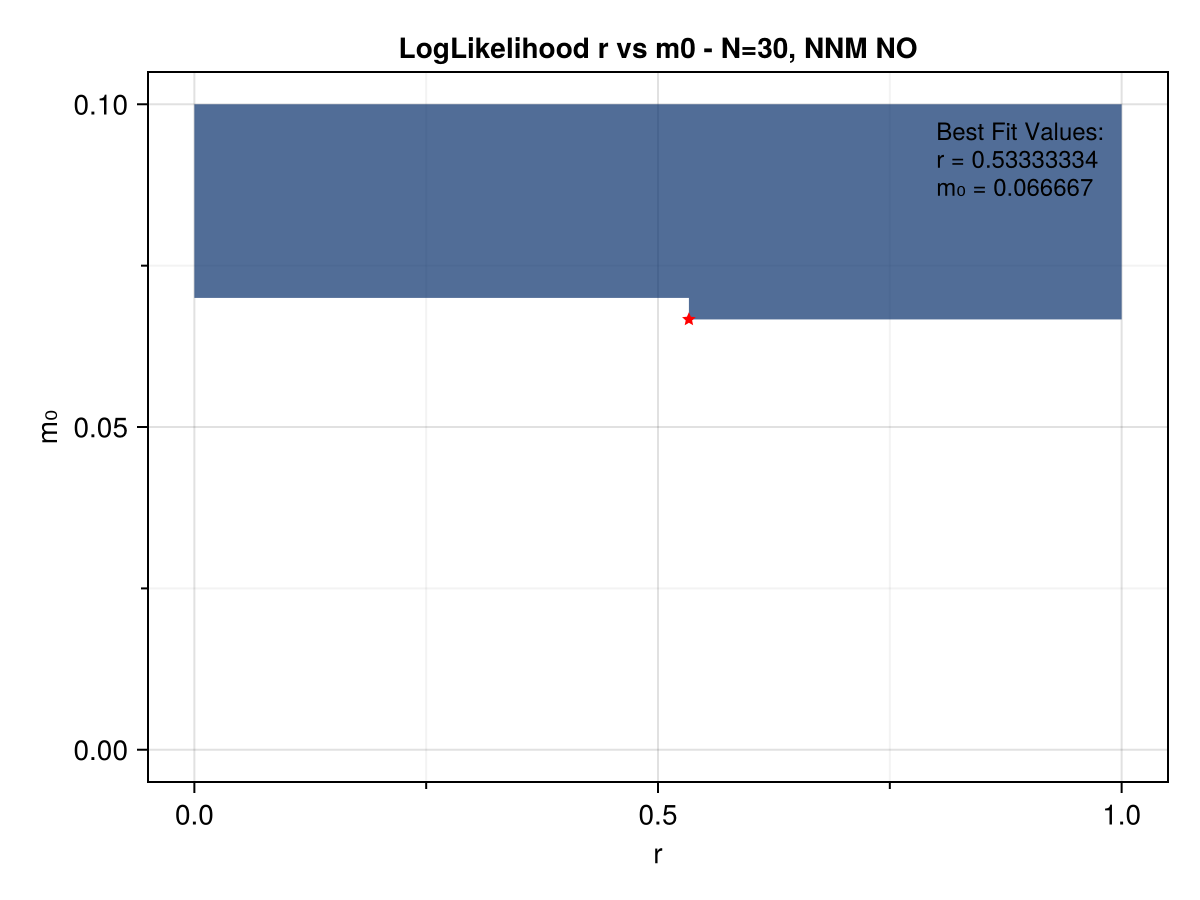

In [614]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood r vs m0 - N=30, NNM NO")
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/gerda_rm0_N30_NNM_NO.png", img)

rindex: 31


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


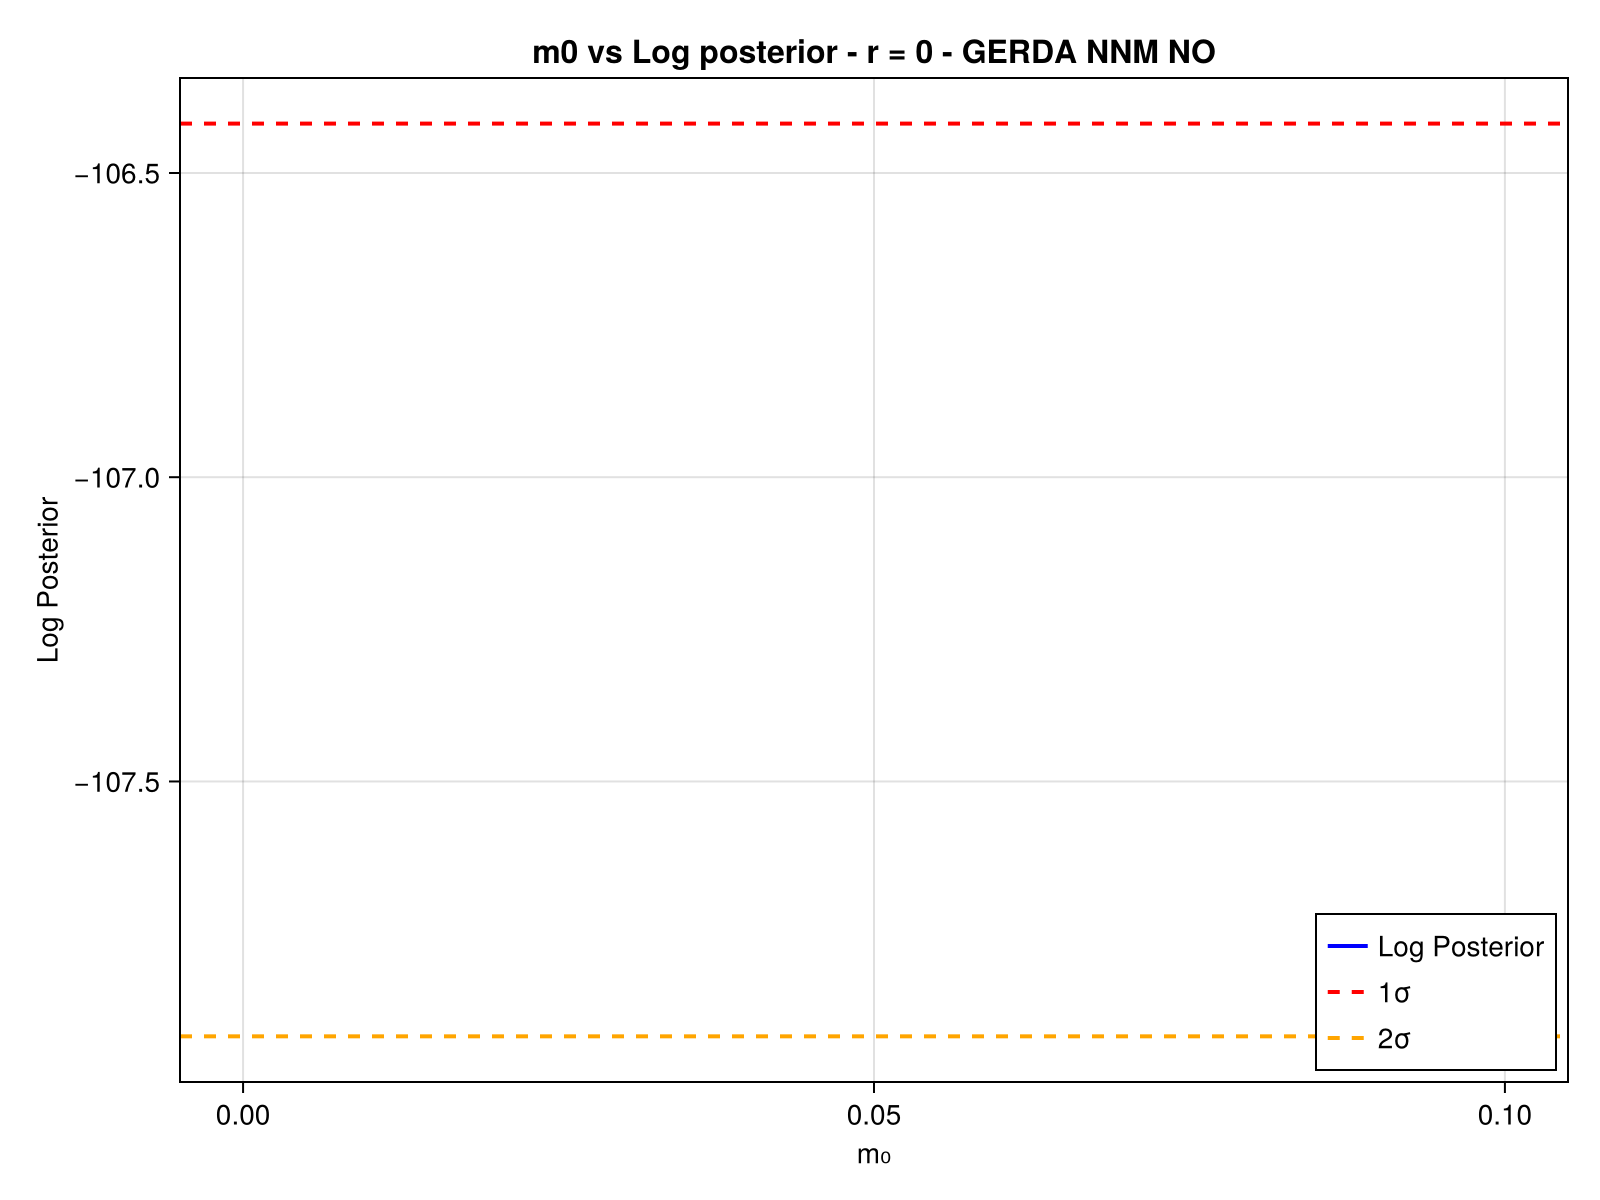

In [617]:
#plot the logposterior value vs r
result = result_NN

#value of r fixed
rfixed =  0#0.00000001
rmax=1
rindex = 31#round(Int, 31/rmax* rfixed)
println("rindex: ", rindex)

#calsculate the best fit
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[rindex ,: ]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[ rindex,: ]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  String(keys(result.axes)[2]),
    ylabel = "Log Posterior",
    title = "m0 vs Log posterior - r = $rfixed - GERDA NNM NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.m₀, result.values.log_posterior[rindex , :],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/gerda_m0Logpost_NNM_NO_N=30_r=$rfixed.png", fig)


m0index: 2


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


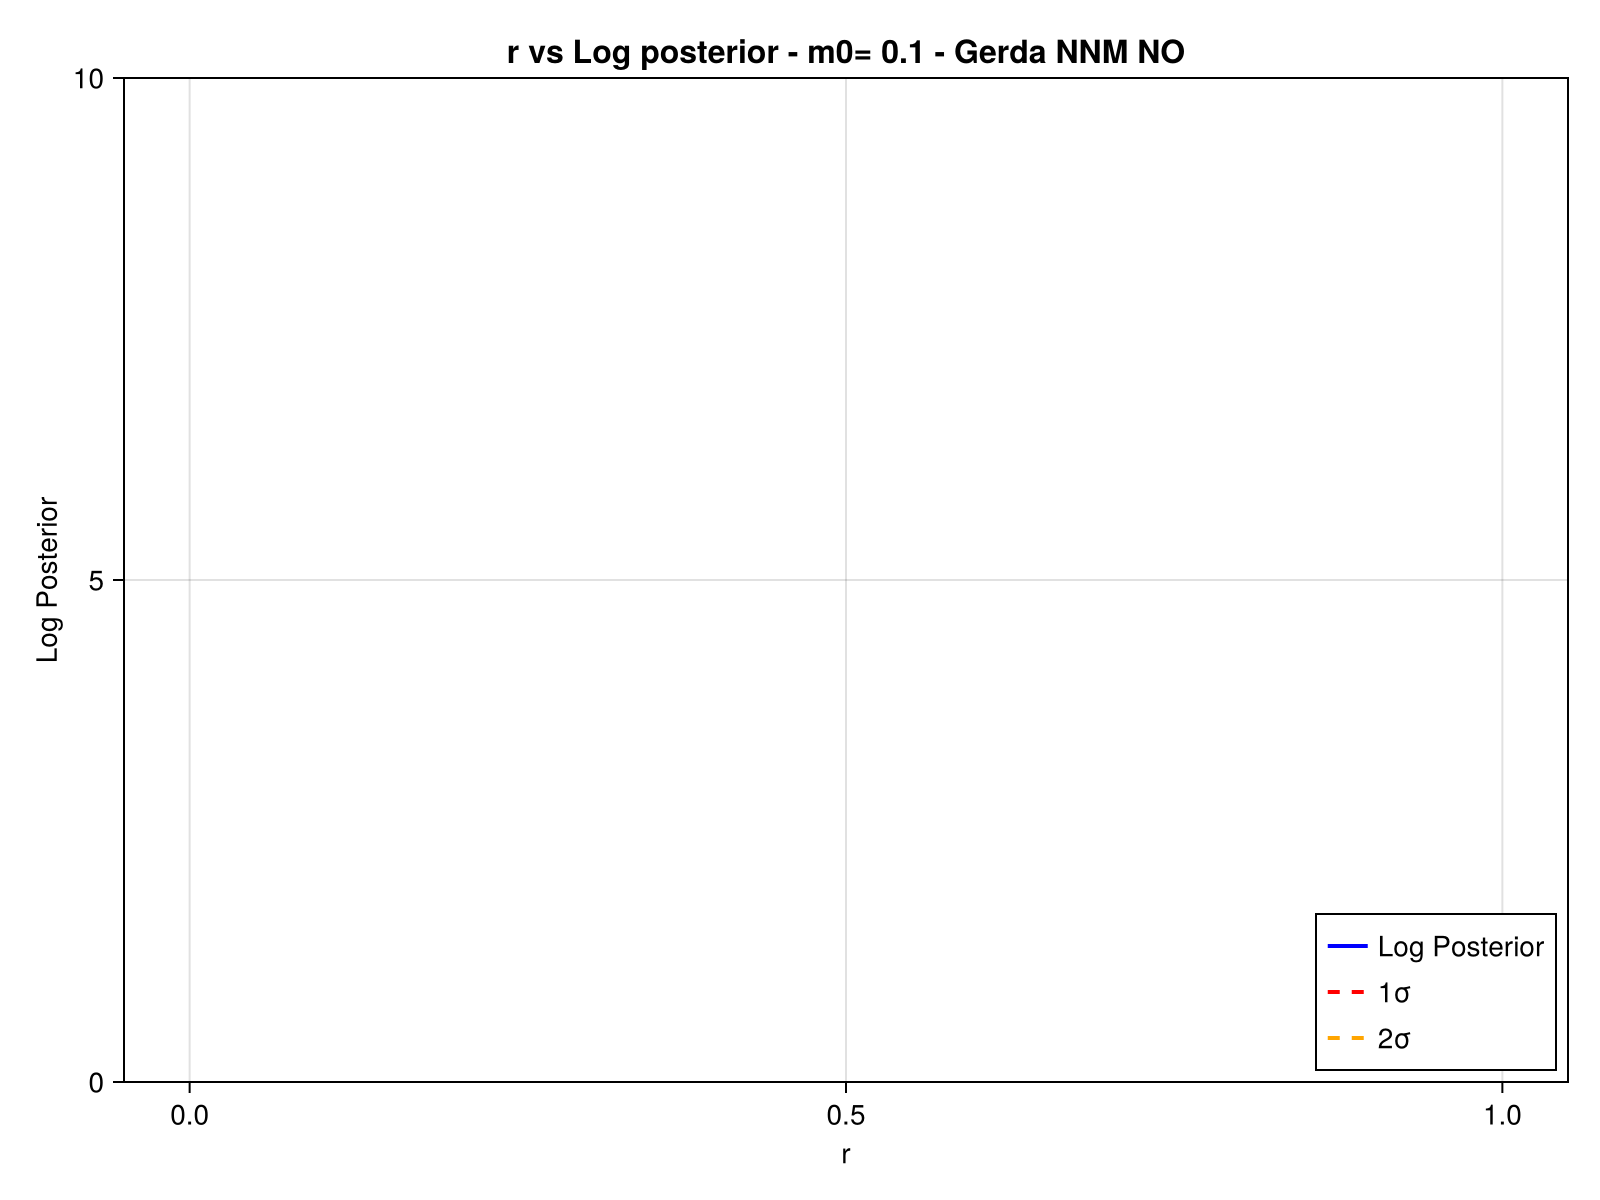

In [616]:

#value of m0 fixed
m0fixed =0.1
m0max=2
m0index = round(Int, 31/m0max* m0fixed)
println("m0index: ", m0index)

#calsculate the best fit
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[:, m0index ]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[:, m0index ]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel =  String(keys(result.axes)[1]),
    ylabel = "Log Posterior",
    title = "r vs Log posterior - m0= $m0fixed - Gerda NNM NO",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.r, result.values.log_posterior[:, m0index],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/gerda_rLogpost_NNM_NO_N=30_m0=$m0fixed.png", fig)
